In [1]:
# 네이버 쇼핑 리뷰 감성 분류 - Okt 버전 전체 코드

!pip install -q konlpy JPype1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 24.9 MB/s eta 0:00:00


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

from collections import Counter
from konlpy.tag import Okt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import Embedding, Dense, GRU
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 네이버 쇼핑 리뷰 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt",
    filename="ratings_total.txt"
)

# 4. 데이터 로드
total_data = pd.read_table(
    'ratings_total.txt',
    names=['ratings', 'reviews']
)

print('전체 리뷰 개수:', len(total_data))
print(total_data.head())

전체 리뷰 개수: 200000
   ratings                                            reviews
0        5                                            배공빠르고 굿
1        2                      택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2        5  아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3        2  선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4        5                  민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [3]:
# 5. 평점을 기준으로 긍정/부정 label 생성
# 평점이 4, 5점이면 긍정 1
# 평점이 1, 2점이면 부정 0
total_data['label'] = np.select(
    [total_data['ratings'] > 3],
    [1],
    default=0
)

print("\nlabel 생성 후 데이터")
print(total_data.head())

print("\n고유값 개수 확인")
print('ratings 고유값 수:', total_data['ratings'].nunique())
print('reviews 고유값 수:', total_data['reviews'].nunique())
print('label 고유값 수:', total_data['label'].nunique())

# 6. 중복 리뷰 제거
total_data = total_data.drop_duplicates(subset=['reviews'])

print('\n중복 제거 후 총 샘플 수:', len(total_data))
print('NULL 값 존재 여부:', total_data.isnull().values.any())

# 7. 결측치 제거
total_data = total_data.dropna(how='any')

print('NULL 제거 후 총 샘플 수:', len(total_data))


label 생성 후 데이터
   ratings                                            reviews  label
0        5                                            배공빠르고 굿      1
1        2                      택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고      0
2        5  아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...      1
3        2  선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...      0
4        5                  민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ      1

고유값 개수 확인
ratings 고유값 수: 4
reviews 고유값 수: 199908
label 고유값 수: 2

중복 제거 후 총 샘플 수: 199908
NULL 값 존재 여부: False
NULL 제거 후 총 샘플 수: 199908



훈련용 리뷰 개수: 149931
테스트용 리뷰 개수: 49977


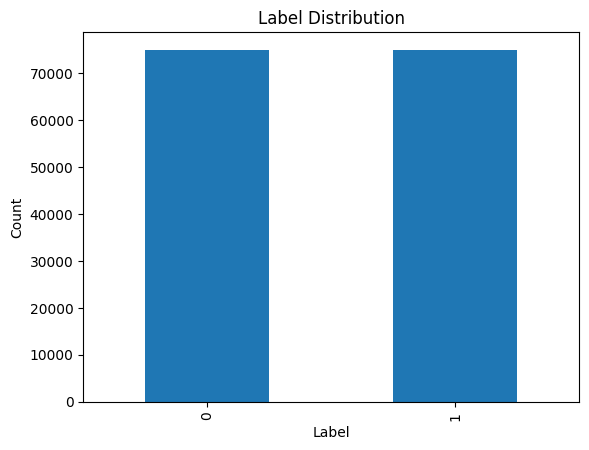


훈련 데이터 label 분포
   label  count
0      0  74966
1      1  74965

전처리 후 훈련용 샘플 수: 149931
전처리 후 테스트용 샘플 수: 49977

훈련 데이터 결측치 확인
ratings    0
reviews    0
label      0
dtype: int64

테스트 데이터 결측치 확인
ratings    0
reviews    0
label      0
dtype: int64

Okt 형태소 분석 테스트
['오다', '이렇다', '것', '도', '상품', '이라고', '차라리', '내', '가', '만들다', '게', '나다', '뻔']

토큰화 결과 확인
                                             reviews  \
0            택배사 좀 바꾸셔야겠어요당일 발송제품이 주일만에 오네요 지역도 서울인데   
1                아이가 사달라고해서 생선으로 구입했습니다 근뎅뭔 맛인지는ㅡㅡㅋㅋ   
2  이유식용으로 구매했어요 딱 생각했던 사이즈에요 평소에 작은 사이즈 도마가 편해서 자...   
3  배송이 이렇게 왔네요ㄷㄷ 다시 펴지지도 않는다는점 구매평도 남겼지만 반품귀찮아 그냥...   
4  고객을 생각하지도 않는 업체인것 같네요 과실로 인해서 고객이 불편을 느끼는데 사과한...   

                                           tokenized  label  
0   [택배, 사, 바꾸다, 당일, 발송, 제품, 주일, 만에, 오다, 지역, 서울, 인데]      0  
1  [아이, 사, 달라, 고해, 서, 생선, 으로, 구입, 하다, 근, 뎅, 뭔, 맛,...      1  
2  [이유, 식용, 으로, 구매, 하다, 딱, 생각, 하다, 사이즈, 에요, 평소, 작...      1  
3  [배송, 이렇게, 오다, ㄷㄷ, 다시, 펴다, 않다, 점, 구, 매, 평, 남기다,...      0  
4 

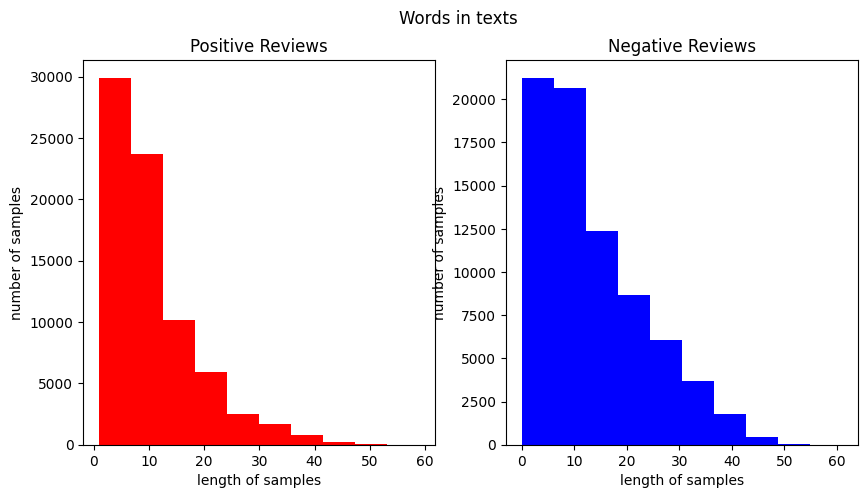


X_train 개수: 149931
y_train 개수: 149931
X_test 개수: 49977
y_test 개수: 49977

단어 집합(vocabulary)의 크기: 36894
등장 빈도가 1번 이하인 희귀 단어의 수: 18085
단어 집합에서 희귀 단어의 비율: 49.018810646717625
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 0.9878535256566071

최종 단어 집합의 크기: 18811

X_train 상위 3개: [[196, 219, 371, 1560, 880, 25, 1561, 337, 19, 3252, 5031, 74], [100, 219, 359, 1151, 55, 2673, 23, 90, 2, 1616, 3055, 1111, 32, 873, 1], [612, 4676, 23, 14, 2, 99, 29, 2, 42, 135, 849, 53, 42, 2567, 52, 346, 17, 8, 371, 39, 87, 1365, 112, 847, 36, 14, 34, 164, 136, 1829, 2877, 20, 732, 105, 1514, 167, 43, 213, 29, 6, 1941, 512, 240, 779, 3]]
X_test 상위 3개: [[471, 409, 595], [181, 17, 31, 2], [104, 43, 533, 21, 1705, 11686, 61]]

리뷰의 최대 길이: 61
리뷰의 평균 길이: 12.210530177214853


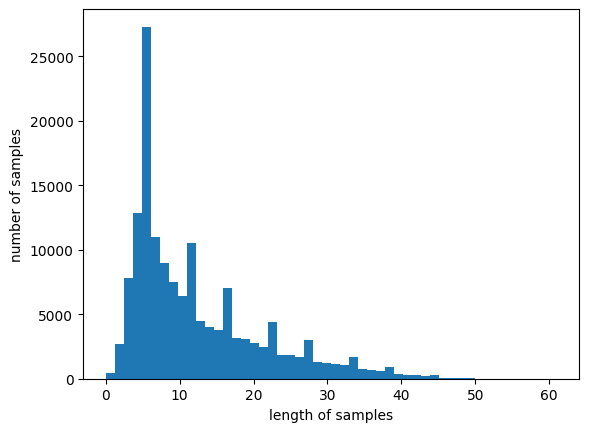

전체 샘플 중 길이가 80 이하인 샘플의 비율: 100.0

X_train shape: (149931, 80)
X_test shape: (49977, 80)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8539 - loss: 0.3611
Epoch 1: val_accuracy improved from None to 0.89429, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 432s 228ms/step - accuracy: 0.8820 - loss: 0.3050 - val_accuracy: 0.8943 - val_loss: 0.2726
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9052 - loss: 0.2539
Epoch 2: val_accuracy improved from 0.89429 to 0.90159, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 416s 222ms/step - accuracy: 0.9059 - loss: 0.2514 - val_accuracy: 0.9016 - val_loss: 0.2561
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9156 - loss: 0.2309
Epoch 3: val_accuracy improved from 0.90159 to 0.90536, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 438s 220ms/step - accuracy: 0.915

In [4]:
# 8. 훈련 데이터와 테스트 데이터 분리
train_data, test_data = train_test_split(
    total_data,
    test_size=0.25,
    random_state=42,
    stratify=total_data['label']
)

# SettingWithCopyWarning 방지를 위해 복사
train_data = train_data.copy()
test_data = test_data.copy()

print('\n훈련용 리뷰 개수:', len(train_data))
print('테스트용 리뷰 개수:', len(test_data))

# 9. 레이블 분포 확인
train_data['label'].value_counts().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

print("\n훈련 데이터 label 분포")
print(train_data.groupby('label').size().reset_index(name='count'))

# 10. 리뷰 정제 함수
def clean_review(text):
    text = str(text)                               # 문자열로 변환
    text = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', text) # 한글과 공백만 남김
    text = re.sub(r'\s+', ' ', text)               # 여러 공백을 하나로 변경
    text = text.strip()                            # 앞뒤 공백 제거
    return text

# 11. 훈련/테스트 리뷰 정제
train_data['reviews'] = train_data['reviews'].apply(clean_review)
test_data['reviews'] = test_data['reviews'].apply(clean_review)

# 빈 문자열을 NaN으로 변경
train_data['reviews'] = train_data['reviews'].replace('', np.nan)
test_data['reviews'] = test_data['reviews'].replace('', np.nan)

# NaN 제거
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

# 인덱스 재정렬
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print('\n전처리 후 훈련용 샘플 수:', len(train_data))
print('전처리 후 테스트용 샘플 수:', len(test_data))
print("\n훈련 데이터 결측치 확인")
print(train_data.isnull().sum())
print("\n테스트 데이터 결측치 확인")
print(test_data.isnull().sum())

# 12. Okt 형태소 분석기 생성
okt = Okt()

# Okt 동작 테스트
print("\nOkt 형태소 분석 테스트")
print(okt.morphs('와 이런 것도 상품이라고 차라리 내가 만드는 게 나을 뻔', stem=True))

# 13. 불용어 목록
stopwords = [
    '도', '는', '다', '의', '가', '이', '은',
    '한', '에', '하', '고', '을', '를', '인',
    '듯', '과', '와', '네', '들', '지', '임', '게',
    '것', '수', '좀', '너무'
]

# 14. 토큰화 및 불용어 제거 함수
def tokenize_and_remove_stopwords(text):
    tokens = okt.morphs(text, stem=True)                 # Okt 형태소 분석
    tokens = [word for word in tokens if word not in stopwords]  # 불용어 제거
    return tokens

# 15. 훈련/테스트 데이터 토큰화
train_data['tokenized'] = train_data['reviews'].apply(tokenize_and_remove_stopwords)
test_data['tokenized'] = test_data['reviews'].apply(tokenize_and_remove_stopwords)

print("\n토큰화 결과 확인")
print(train_data[['reviews', 'tokenized', 'label']].head())

# 16. 긍정/부정 리뷰 단어 빈도 확인
negative_words = np.hstack(
    train_data[train_data['label'] == 0]['tokenized'].values
)

positive_words = np.hstack(
    train_data[train_data['label'] == 1]['tokenized'].values
)

negative_word_count = Counter(negative_words)
positive_word_count = Counter(positive_words)

print('\n부정 리뷰 빈도 상위 20개')
print(negative_word_count.most_common(20))

print('\n긍정 리뷰 빈도 상위 20개')
print(positive_word_count.most_common(20))

# 17. 리뷰 길이 분포 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

positive_len = train_data[train_data['label'] == 1]['tokenized'].map(lambda x: len(x))
ax1.hist(positive_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('\n긍정 리뷰의 평균 길이:', np.mean(positive_len))

negative_len = train_data[train_data['label'] == 0]['tokenized'].map(lambda x: len(x))
ax2.hist(negative_len, color='blue')
ax2.set_title('Negative Reviews')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이:', np.mean(negative_len))

fig.suptitle('Words in texts')
plt.show()

# 18. 입력 데이터와 정답 데이터 분리
X_train = train_data['tokenized'].values
y_train = train_data['label'].values

X_test = test_data['tokenized'].values
y_test = test_data['label'].values

print('\nX_train 개수:', len(X_train))
print('y_train 개수:', len(y_train))
print('X_test 개수:', len(X_test))
print('y_test 개수:', len(y_test))

# 19. Tokenizer 학습
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# 20. 희귀 단어 비율 확인
threshold = 2
total_cnt = len(tokenizer.word_index)
rare_cnt = 0
total_freq = 0
rare_freq = 0

for key, value in tokenizer.word_counts.items():
    total_freq += value

    if value < threshold:
        rare_cnt += 1
        rare_freq += value

print('\n단어 집합(vocabulary)의 크기:', total_cnt)
print('등장 빈도가 {}번 이하인 희귀 단어의 수: {}'.format(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어의 비율:', (rare_cnt / total_cnt) * 100)
print('전체 등장 빈도에서 희귀 단어 등장 빈도 비율:', (rare_freq / total_freq) * 100)

# 21. 희귀 단어를 제외한 단어 집합 크기 설정
vocab_size = total_cnt - rare_cnt + 2
print('\n최종 단어 집합의 크기:', vocab_size)

# 22. 제한된 단어 집합으로 Tokenizer 재생성
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token='OOV'
)

tokenizer.fit_on_texts(X_train)

# 23. 텍스트를 정수 시퀀스로 변환
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)
print('\nX_train 상위 3개:', X_train[:3])
print('X_test 상위 3개:', X_test[:3])

# 24. 리뷰 길이 확인
print('\n리뷰의 최대 길이:', max(len(review) for review in X_train))
print('리뷰의 평균 길이:', sum(map(len, X_train)) / len(X_train))

plt.hist([len(review) for review in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

# 25. 특정 길이 이하 샘플 비율 확인 함수
def below_threshold_len(max_len, nested_list):
    count = 0

    for sentence in nested_list:
        if len(sentence) <= max_len:
            count += 1

    print(
        '전체 샘플 중 길이가 {} 이하인 샘플의 비율: {}'.format(
            max_len,
            (count / len(nested_list)) * 100
        )
    )

# 26. 패딩 기준 길이 설정
max_len = 80
below_threshold_len(max_len, X_train)

# 27. 패딩
X_train = pad_sequences(
    X_train,
    maxlen=max_len
)

X_test = pad_sequences(
    X_test,
    maxlen=max_len
)

print('\nX_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

# 28. GRU 감성 분류 모델 생성
embedding_dim = 100
hidden_units = 128

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
)

model.add(
    GRU(hidden_units)
)

model.add(
    Dense(1, activation='sigmoid')
)

# 29. EarlyStopping 설정
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=4
)

# 30. ModelCheckpoint 설정
mc = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True
)

# 31. 모델 컴파일
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 32. 모델 구조 출력
model.summary()

# 33. 모델 학습
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    callbacks=[es, mc],
    batch_size=64,
    validation_split=0.2
)

In [5]:
# 34. 최적 모델 불러오기
loaded_model = load_model('best_model.keras')

# 35. 테스트 데이터 평가
loss, accuracy = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n테스트 정확도: %.4f" % accuracy)

# 36. 새 리뷰 감성 예측 함수
def sentiment_predict(new_sentence):
    new_sentence = re.sub(
        r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]',
        '',
        new_sentence
    )

    new_sentence = okt.morphs(
        new_sentence,
        stem=True
    )

    new_sentence = [
        word for word in new_sentence
        if word not in stopwords
    ]

    encoded = tokenizer.texts_to_sequences(
        [new_sentence]
    )

    pad_new = pad_sequences(
        encoded,
        maxlen=max_len
    )

    score = float(
        loaded_model.predict(
            pad_new,
            verbose=0
        )[0][0]
    )

    if score > 0.5:
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

# 37. 예측 테스트
sentiment_predict('이 상품 진짜 좋아요... 저는 강추합니다. 대박')
sentiment_predict('진짜 배송도 늦고 개짜증나네요. 뭐 이런 걸 상품이라고 만듬?')

1562/1562 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.9135 - loss: 0.2410

테스트 정확도: 0.9135
97.62% 확률로 긍정 리뷰입니다.
99.50% 확률로 부정 리뷰입니다.
